Number of points: 20
Initial route: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
Shuffled initial route: [ 7 10 16 13  2  6 11 19 17  8  9  0  5  4 12 15 18 14  1  3]
Best route:
[ 2 11 12 14  3  6  9 10  7 15 18 17 16  1  5 13  8  0  4 19]
Best cost:
4.008447998309261


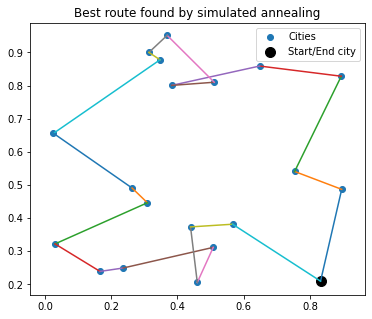

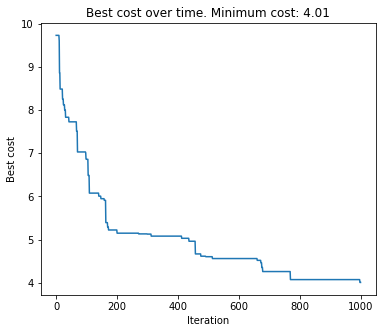

In [1]:
# Exercise 7 - Part 1

import numpy as np
import matplotlib.pyplot as plt


def route_cost(route, points):
    """
    Compute total cost of a closed route using Euclidean distance.
    """
    total = 0
    n = len(route) # number of cities

    for i in range(n):
        current_city = route[i]
        next_city = route[(i + 1) % n]

        total += np.linalg.norm(points[current_city] - points[next_city])

    return total


def propose_swap(route):
    """
    Create a new route by swapping two randomly chosen cities.
    """
    new_route = route.copy()

    i, j = np.random.choice(len(route), size=2, replace=False)
    new_route[i], new_route[j] = new_route[j], new_route[i]

    return new_route


def temperature(k):
    """
    Cooling schedule.
    """
    return 1 / np.sqrt(1 + k)


def simulated_annealing(points, num_iterations):
    """
    Simulated annealing algorithm for the travelling salesman problem.
    """
    #print("Initial points:")
    #print(points)
    print("Number of points:", len(points))
    n = len(points)

    # Start with a random route
    current_route = np.arange(n)
    print("Initial route:", current_route)
    np.random.shuffle(current_route)
    print("Shuffled initial route:", current_route)

    current_cost = route_cost(current_route, points)

    # Store best route found so far
    best_route = current_route.copy()
    best_cost = current_cost

    costs = []

    for k in range(num_iterations):
        T = temperature(k)

        # Generate candidate by swapping two cities
        candidate_route = propose_swap(current_route)
        candidate_cost = route_cost(candidate_route, points)

        delta = candidate_cost - current_cost

        # Accept if candidate is better
        if delta <= 0:
            current_route = candidate_route
            current_cost = candidate_cost

        # Otherwise accept with probability exp(-delta / T)
        else:
            acceptance_probability = np.exp(-delta / T)

            if np.random.rand() < acceptance_probability:
                current_route = candidate_route
                current_cost = candidate_cost

        # Update best solution
        if current_cost < best_cost:
            best_route = current_route.copy()
            best_cost = current_cost

        costs.append(best_cost)

    return best_route, best_cost, costs


# number of cities
n = 20

#point_type = "unit_circle"
point_type = "unit_square"

if point_type == "unit_square":
    points = np.random.rand(n, 2)

elif point_type == "unit_circle":
    theta = np.linspace(0, 2*np.pi, n, endpoint=False)

    points = np.column_stack((
        np.cos(theta),
        np.sin(theta)
    ))

# Run simulated annealing
best_route, best_cost, costs = simulated_annealing(
    points,
    num_iterations=1000
)

print("Best route:")
print(best_route)

print("Best cost:")
print(best_cost)


plt.figure(figsize=(6, 5))

for i in range(len(best_route)):
    p1 = points[best_route[i]]
    p2 = points[best_route[(i + 1) % len(best_route)]]

    plt.plot([p1[0], p2[0]], [p1[1], p2[1]])

plt.scatter(points[:, 0], points[:, 1], label="Cities")
plt.scatter(points[best_route[0], 0], points[best_route[0], 1], color="black", s=100, label="Start/End city")
plt.axis("equal")
plt.title("Best route found by simulated annealing")
plt.legend()
plt.savefig("best_route.png", dpi=300)
plt.show()


plt.figure(figsize=(6, 5))
plt.plot(costs)
plt.xlabel("Iteration")
plt.ylabel("Best cost")
plt.title("Best cost over time. Minimum cost: {:.2f}".format(best_cost))
plt.savefig("best_cost_over_time.png", dpi=300)
plt.show()



Best route:
[ 8 13  1  6 10 19  2 17 16  4 15  7  9  0  5 11 12  3 18 14]
Best cost:
1167


<ipython-input-3-849225254909>:90: RuntimeWarning: overflow encountered in true_divide
  acceptance_probability = np.exp(-delta / T)
<ipython-input-3-849225254909>:90: RuntimeWarning: divide by zero encountered in true_divide
  acceptance_probability = np.exp(-delta / T)


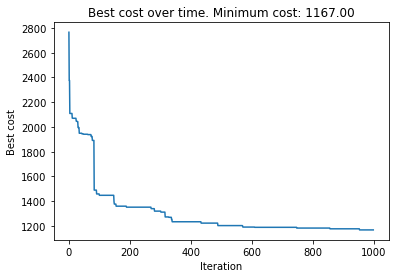

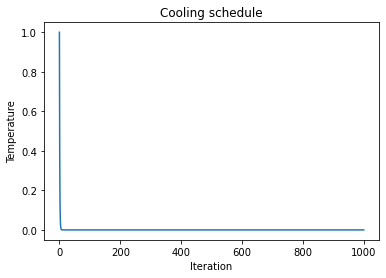

In [3]:
# Exercise 7 - Part 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def route_cost(route, cost_matrix):
    """
    Computes the total cost of a route (using the cost matrix).

    input: the ordering of the cities. NB the route returns to the starting city. 
    """
    total = 0
    n = len(route)

    for i in range(n):
        current_city = route[i]
        next_city = route[(i + 1) % n] # modulu operator wraps the route back to the starting city
        total += cost_matrix[current_city, next_city]

    return total


def propose_swap(route):
    """
    Generate a new candidate route Yi from the current state Xi by swapping two random cities.
    """
    new_route = route.copy() # copying because we only want to modify the currentroute, if the algorithm accepts the new route

    i, j = np.random.choice(len(route), size=2, replace=False) # a city can not be swapped with itself because of replace=False
    new_route[i], new_route[j] = new_route[j], new_route[i]

    return new_route

def proposal_2opt(route):
    """
    Create a new route by selecting one random segment and swapping it with its left neighbour.
    Example: If the route is [0, 1, 2, 3, 4] and we select index 2, the new route will be [0, 2, 1, 3, 4].
    """
    new_route = route.copy()

    i = np.random.randint(1, len(route) - 1)
    new_route[i-1], new_route[i] = new_route[i], new_route[i-1]

    return new_route


def temperature(k):
    """
    Cooling scheme:
    """
    #return - k
    #return 1 / np.sqrt(1 + k)
    #return 1 / np.log(2 + k)
    return np.exp(-k)


def simulated_annealing(cost_matrix, num_iterations):
    n = cost_matrix.shape[0] # number of cities

    # Initial route
    current_route = np.arange(n)
    np.random.shuffle(current_route) # shuffle the initial route to start with a random one

    current_cost = route_cost(current_route, cost_matrix)

    best_route = current_route.copy() # initialize best route as the initial route
    best_cost = current_cost          # initialize best cost as the cost of the initial route

    costs = []

    for k in range(num_iterations):
        T = temperature(k)

        candidate_route = propose_swap(current_route)
        #candidate_route = proposal_2opt(current_route)
        candidate_cost = route_cost(candidate_route, cost_matrix)

        # Difference in cost
        delta = candidate_cost - current_cost

        # Accept if better
        if delta <= 0:
            current_route = candidate_route
            current_cost = candidate_cost

        # If not better, still accept with probability exp(-delta / T)
        else:
            acceptance_probability = np.exp(-delta / T)

            if np.random.rand() < acceptance_probability:
                current_route = candidate_route
                current_cost = candidate_cost

        # Save best solution found so far
        if current_cost < best_cost:
            best_route = current_route.copy()
            best_cost = current_cost

        costs.append(best_cost)

    return best_route, best_cost, costs


# Load cost matrix from CSV
cost_matrix = pd.read_csv("cost.csv", header=None).values

best_route, best_cost, costs = simulated_annealing(
    cost_matrix,
    num_iterations=1000
)

print("Best route:")
print(best_route)

print("Best cost:")
print(best_cost)


# Plot improvement of best cost
plt.plot(costs)
plt.xlabel("Iteration")
plt.ylabel("Best cost")
plt.title("Best cost over time. Minimum cost: {:.2f}".format(best_cost))
#plt.savefig("best_cost_over_time_.png", dpi=300)
plt.show()

# PLot of cooling schedule
plt.plot([temperature(k) for k in range(1000)])
plt.xlabel("Iteration")
plt.ylabel("Temperature")
plt.title("Cooling schedule")
plt.show()